# Binary Search

* Binary Search is an algorithm that is generally used to find the position of a specific element within a sorted array (***or nearly sorted***). 
* Here:
    * the array is divided into the **left-half** and the **right-half** based on the **middle element**,
    * and, depending on the value of the element that is searched, we need to search in the **left-half** or the **right-half** of the array.
* **`mid = (left index + right index) / 2`** - this can have integer overflow if both left & right indices are too large, since we're adding them.
* **`mid = left + (right index - left index) / 2`**  - this is an optimized form to prevent integer overflow.

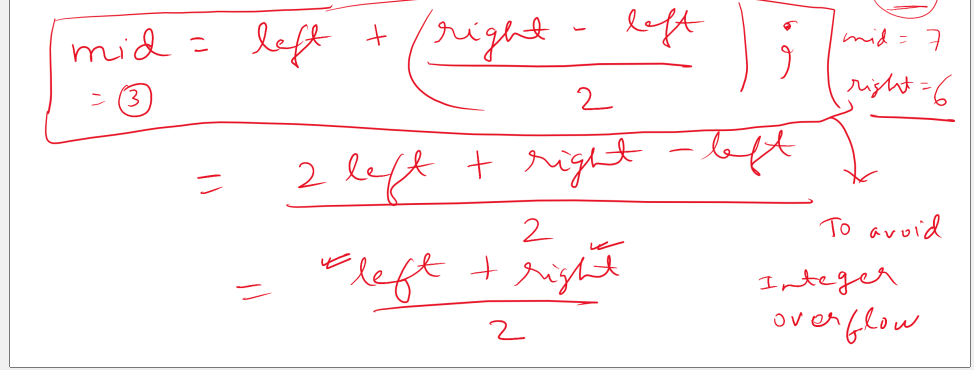

---

**Each time, you will compare the target element with the middle element**:
* If matched, then return the index.
* Otherwise, divide the array into the **left-half** and the **right-half**.
* Based on the element to be searched, either look into the **left-half** or into the **right-half**.

---

**Core idea**:
* If `mid-value < target` → go **right**
* If `mid-value > target` → go **left**
* Else → **target found**

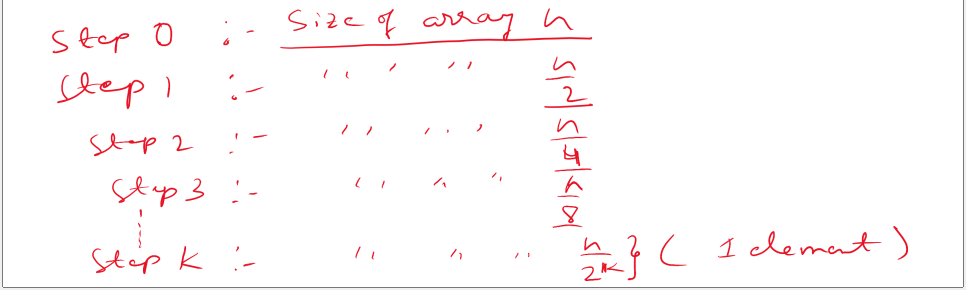

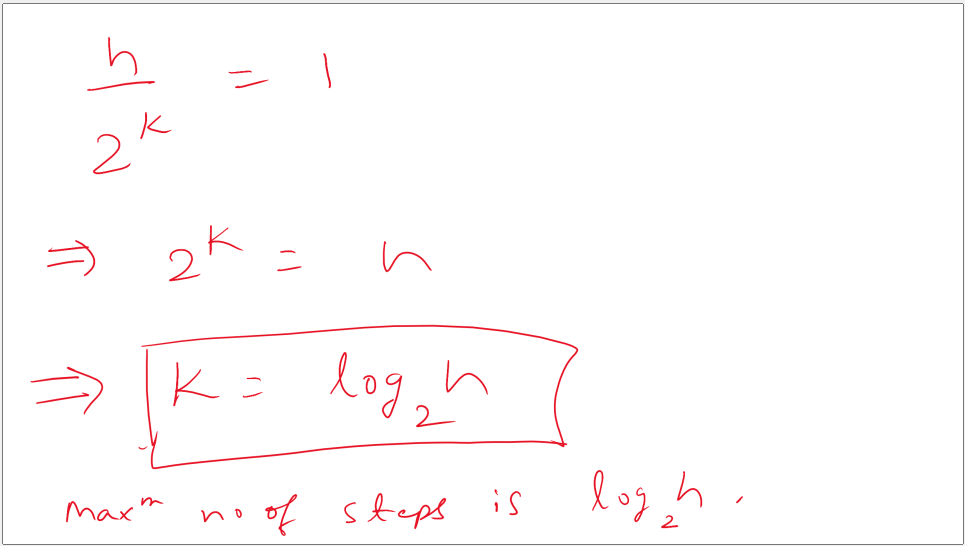

---

* **Binary Search** is a technique used to **find an element in a sorted array** efficiently by repeatedly dividing the search space in half.
* It follows the **Divide & Conquer** strategy.
* Worst Case Time Complexity: **`O(log n)`**

> Whenever in an interview, you have provided the solution by **`O(n)`**, but your interviewer still asks you for a **better Time Complexity**, then in that situation go for **BINARY SEARCH** as its time complexity is **`O(log n)`** < **`O(n)`**.

**Binary Search** can be implemented in two ways:
1. Iterative Ways
2. Recursive Ways

# Recursion

Tricks to keep in mind while using **RECURSION**:
1. **Identify the parameters** that you will need to use to solve the problem.
2. Think of the **Base Condition** - that is, when to stop recursion.
3. Make recursive function calls by **changing the parameter value during the recursion call**.
4. **Return the appropriate value** back to its parent function call, depending on the problem.

# Example: Binary Search using Iteration

In [4]:
def binary_search(arr, target, low, high):

    while low < high:
        mid = low + ((high - low) // 2)
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

arr = [11, 21, 31, 40, 58, 68, 79, 90]
target = 21

low = 0
high = len(arr) - 1

print(binary_search(arr, target, low, high))

1


**Time Complexity**: `O(logn)`

**Space Complexity**: `O(1)`

# Example: Binary Search using Recursion

In [3]:
def binary_search(arr, target, low, high):

    if low > high:
        return -1

    mid = low + ((high - low) // 2)

    if arr[mid] == target:
        return mid
    elif arr[mid] < target:
        index = binary_search(arr, target, mid + 1, high)
        return index
    else:
        index = binary_search(arr, target, low, mid -1)
        return index

arr = [11, 21, 31, 40, 58, 68, 79, 90]
target = 21
low = 0
high = len(arr) - 1

print(binary_search(arr, target, low, high))

1


Here, the significance of the recursive function is that it returns the **index** of the **target** element in the array.
* **Parameters**: `arr`, `target`, `low`, `high`.
* **Base condition**: when `low` crosses `high` (`low > high`).

**Time Complexity**: `O(log n)`

**Space Complexity**: `O(log n)` due to recursive stack

# Problem 1: Binary Search with Rotation Awareness

Given the array nums after the possible rotation and an integer target, return the index of target if it is in nums, or -1 if it is not in nums.

**Input**: 
```
nums = [4,5,6,7,0,1,2],
target = 0
```

**Output**: `4`

> **NOTE**: Here, the array is not completely sorted. But still, we can use Binary Search, since it's partially sorted (**Nearly Sorted**).

# Solution 1 (Using Iterative approach)

## ✅ 1. Pattern of the Problem

The array was originally sorted in ascending order, but then rotated at some pivot.

**Example:**
* Original sorted → `[0,1,2,4,5,6,7]`
* After rotation → `[4,5,6,7,0,1,2]`

So even though the array looks unsorted, it still has a special pattern.

**✅ Exactly one half of the array is always sorted.**

At any point during binary search:
* Either the **left half is sorted**,
* or the **right half is sorted**

This is the key property that allows binary search in **`O(log n)`** time.

## ✅ 2. Intuition Behind the Solution

A normal binary search works only on a fully sorted array.

Here, due to rotation:
* The overall array isn’t sorted
* But **one side of mid will always be sorted**

So at each step:
* **Check which half is sorted**
* **Check if the target lies inside that sorted half**
    * If `yes` → binary search that half
    * If `no` → search the other half

We shrink the search space by half each time → **`O(log n)`**.

In [6]:
def binary_search(arr, target):
    low = 0
    high = len(arr) - 1

    while low <= high:
        mid = (low + high) // 2

        # Case 1: Target found
        if arr[mid] == target:
            return mid   # Found

        # Case 2: Left half is sorted
        if arr[low] <= arr[mid]:
            # Check if target lies within the sorted left half
            if arr[low] <= target < arr[mid]:
                high = mid - 1  # Left half
            else:
                low = mid + 1  # Right half 
        
        # Case 3: Right half is sorted
        else:
            # Check if target lies within the sorted right half
            if arr[mid] < target <= arr[high]:
                low = mid + 1  # Right half
            else:
                high = mid - 1  # Left half
            
    return -1  # Not found

arr = [4,5,6,7,0,1,2]
target = 0
print(binary_search(arr, target))

4


**Time Complexity**: `O(logn)`

**Space Complexity**: `O(1)`

# Problem 2

Given a sorted array of non-negative distinct integers, find the smallest missing non-negative element in it.

**Input**:  `nums[] = [0, 1, 2, 6, 9, 11, 15]`

**Output**: The smallest missing element is `3`


# Solution (Iterative)

## ✅ 1. Pattern of the Problem

You are given:
* A **sorted array**
* Values are **distinct**
* Values are **non‑negative integers**

Example: `[0, 1, 2, 6, 9, 11, 15]`

**✅ Key Pattern**

If the array had no missing numbers, each element would follow:

```
nums[i] == i
```

**For example:**

Index: `0 1 2 3 4 5`

Value: `0 1 2 3 4 5`   → perfectly aligned

The first place where this condition breaks **(`nums[i] != i`)** is the **smallest missing non‑negative integer**.

## ✅ 2. Intuition

We want the first mismatch between: **index `i` and value `nums[i]`**

Because the array is sorted:
* If `nums[mid] == mid` → left side is perfect → **missing number is on the right**
* If `nums[mid] > mid` → **mismatch occurs here or to the left**

We can use **binary search** because the mismatch pattern is monotonic:
* ✔ All good indices before the missing number: `nums[i] == i`
* ✘ All indices after missing number: `nums[i] > i`

The transition is **monotonic**, making binary search valid → **`O(log n)`** solution.

## ✅ 3. Technique: Binary Search for First Mismatch

**Steps:**

```
Initialize low = 0, high = n - 1

While low ≤ high:
    Compute mid
    If nums[mid] == mid:
        → Missing number is on the right → low = mid + 1
    Else (nums[mid] > mid):
        → Mismatch at or before mid → move left → high = mid - 1
    Loop ends when low is pointing directly to the smallest missing number.

✅ The final answer = low
```

In [7]:
def smallest_missing_number(nums):
    low, high = 0, len(nums) - 1

    while low <= high:
        mid = (low + high) // 2

        # If value matches the index → left side perfect → go right
        if nums[mid] == mid:
            low = mid + 1
        else:
            # Mismatch found → smallest missing is on left or at mid
            high = mid - 1

    # When loop ends, low points to the first index where nums[i] != i
    return low

nums = [0, 1, 2, 6, 9, 11, 15]
print(smallest_missing_number(nums))   # Output: 3


3


**Time Complexity**: `O(logn)`

**Space Complexity**: `O(1)`

# Solution (Recursive)

## ✅ Why This Recursive Approach Works

The array satisfies:
* Sorted
* Distinct
* Non‑negative

So the pattern is:
* Before the missing number: `nums[i] == i`
* At and after missing number: `nums[i] > i`

This is a **monotonic condition**, which is perfect for binary search.

The recursive logic:

**✅ If `nums[mid] == mid`**
* Left part is perfect → the missing element must be on the **right**
* → recurse on (`mid + 1, high`)

**✅ If `nums[mid] > mid`**
* Mismatch begins here → missing element is in the **left part or at mid**
* → recurse on (`low, mid - 1`)

**✅ Base Case**
* When the search collapses (`low > high`),
* low is pointing at the first mismatch → missing number.

In [10]:
def smallest_missing_recursive(nums, low, high):
    # Base condition:
    # When low crosses high → low is the first index where nums[i] != i
    if low > high:
        return low

    mid = low + (high - low) // 2

    # If value matches index → left portion is perfect → search right
    if nums[mid] == mid:
        return smallest_missing_recursive(nums, mid + 1, high)
    else:
        # Mismatch → missing is at mid or left side
        return smallest_missing_recursive(nums, low, mid - 1)


nums = [0, 1, 2, 6, 9, 11, 15]
print(smallest_missing_number(nums))  # Output: 3

3


**Time Complexity**: `O(log n)`

**Space Complexity**: `O(log n)` due to recursive stack